In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487060177069
V1.0.0.8
V10.1

In [63]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V4C-934.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 74214 entries, 0 to 74213
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  74214 non-null  str  
 1   Message  74214 non-null  str  
 2   Status   74214 non-null  str  
dtypes: str(3)
memory usage: 1.7 MB


In [64]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252523    64756
0x252514     7197
0x252513     1974
0x252501      186
0x252511      101
Name: count, dtype: int64

In [65]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 74214 entries, 0 to 74213
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  74214 non-null  str  
 1   Message  74214 non-null  str  
 2   Status   74214 non-null  str  
 3   Headers  74214 non-null  str  
dtypes: str(4)
memory usage: 2.3 MB


Odometer

In [66]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 9171 entries, 3 to 74213
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             9171 non-null   str  
 1   Message             9171 non-null   str  
 2   Status              9171 non-null   str  
 3   Headers             9171 non-null   str  
 4   Odometer in meters  9171 non-null   int64
 5   Date                9171 non-null   str  
 6   Raw data            9171 non-null   str  
dtypes: int64(1), str(6)
memory usage: 573.2 KB
None


260923062410 -> 0 -> 2381615.0 -> 0x252513005913900869487060177069003C38402D0000294B800000000700644100000000000004FFFFFFFFFFFF00D50024572F3626092306241082CC000A02CD8267C5A9013A01E6000003721217FFFFFF000011FFFFFFFFFF
260923062410 -> 1 -> 2381615.0 -> 0x252514005936910869487060177069003C38402D0000294B000000000700644100000000000000FFFFFFFFFFFF16D50024572F3626092306241082CC000A02CD8267C5A9013A01E6000003721239FFFFFF000011FFFFFFFFFF
260923062411 -> 2 -> 2381615.0 -> 0x252514005936920869487060177069003C38402D0000294B000000000700640000000000040003FFFFFFFFFFFF17D50024572F3726092306241182CC000A02CD8267C5A9013A01E6000003720964FFFFFF000011FFFFFFFFFF
260923062413 -> 3 -> 2381615.0 -> 0x252514005936930869487060177069003C38402D0000294B000000000700644100000000000004FFFFFFFFFFFF16D50024572F3726092306241382CC000A02CD8267C5A9013A01E6000003721389FFFFFF000011FFFFFFFFFF
260923062611 -> 4 -> 2381615.0 -> 0x252513005913910869487060177069003C38402D00002959520000000700644100000000000002FFFFFFFFFFFF00D50024572F45

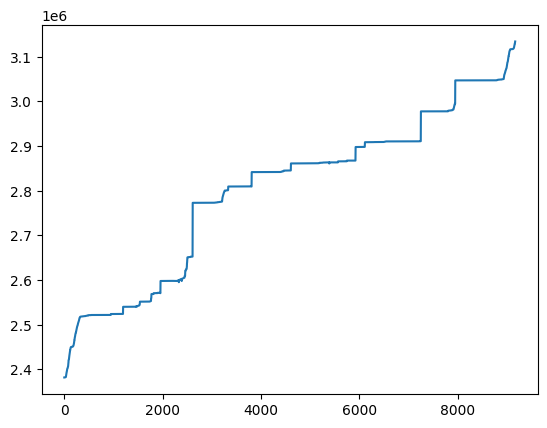

In [67]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [68]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


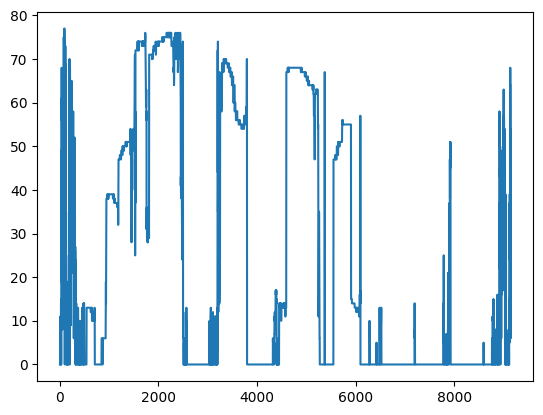

In [69]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historical events

In [70]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 0b10000000)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

print(satellite_connection_indicator)
unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

[128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Satellites Number

In [71]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 9171 entries, 3 to 74213
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         9171 non-null   str  
 1   Message                         9171 non-null   str  
 2   Status                          9171 non-null   str  
 3   Headers                         9171 non-null   str  
 4   Satellites                      9171 non-null   int64
 5   Satellite_connection_indicator  9171 non-null   int64
 6   Raw data                        9171 non-null   str  
 7   date                            9171 non-null   str  
dtypes: int64(2), str(6)
memory usage: 644.8 KB
128 -> 2026-09-23 06:24:10.897 -> 0 -> 0x252513005913900869487060177069003C38402D0000294B800000000700644100000000000004FFFFFFFFFFFF00D50024572F3626092306241082CC000A02CD8267C5A9013A01E6000003721217FFFFFF000011FFFFFFFFFF
0 -> 2026-09-23 06:24:10.677 -> 0 -> 0x252514005936

Coordinates

In [72]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 9171 entries, 3 to 74213
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            9171 non-null   str    
 1   Message            9171 non-null   str    
 2   Status             9171 non-null   str    
 3   Headers            9171 non-null   str    
 4   Latitude           9171 non-null   str    
 5   Latitude_decoded   9171 non-null   float64
 6   Longitude          9171 non-null   str    
 7   Longitude_decoded  9171 non-null   float64
 8   Raw data           9171 non-null   str    
 9   Date               9171 non-null   str    
 10  Speed              9171 non-null   int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 859.8 KB
None
260923062410 -> C5A9013A -> 0.0004946257104165852 -> 02CD8267 -> 1.2353787388467048e+24 0x252513005913900869487060177069003C38402D0000294B800000000700644100000000000004FFFFFFFFFFFF00D50024572F3626092306241082CC000A02CD8

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [73]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\in_outs_V4C-934.csv')

<class 'pandas.DataFrame'>
Index: 9171 entries, 3 to 74178
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9171 non-null   str  
 1   Message  9171 non-null   str  
 2   Status   9171 non-null   str  
 3   Headers  9171 non-null   str  
dtypes: str(4)
memory usage: 358.2 KB


Ignition

In [74]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 9133 entries, 0 to 1935
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  9133 non-null   str  
 1   date         9133 non-null   str  
 2   raw data     9133 non-null   str  
dtypes: str(3)
memory usage: 285.4 KB
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition Off 0b0
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b10000010000

Door detection

In [75]:
x='0b0011000000000000' # for 16 bits, len=18

print(len(x),(x[4:6]))

y='0b011000000000000'   # for 15 bits, len=17
print(len(y), (y[3:5]))


18 11
17 11


In [76]:
in_outs=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\in_outs_V4C-934.csv',sep=',')
in_outs.info()
for i in range(0,in_outs.shape[0]):
    aux=(in_outs.iloc[i,1])
    if len(aux)==18:
        aux_2=(in_outs.iloc[i,1][4:6])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)
    if len(aux)==17:
        aux_2=(in_outs.iloc[i,1][3:5])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)

<class 'pandas.DataFrame'>
RangeIndex: 9133 entries, 0 to 9132
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   9133 non-null   int64
 1   in and outs  9133 non-null   str  
 2   date         9133 non-null   int64
 3   raw data     9133 non-null   str  
dtypes: int64(2), str(2)
memory usage: 285.5 KB


Panic detection

In [77]:
unit_.info()

<class 'pandas.DataFrame'>
RangeIndex: 9133 entries, 0 to 9132
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  9133 non-null   str  
 1   date         9133 non-null   str  
 2   raw data     9133 non-null   str  
dtypes: str(3)
memory usage: 214.2 KB


In [78]:
for i in range(0,unit_.shape[0]):
    if unit_.iloc[i,2][92:94]=='42':
        print(unit_.iloc[i,2],unit_.iloc[i,1])

iButton

In [79]:
id_button_m=raw_data[raw_data['Headers'].str.contains('0x252523')]
device_id=[]
id_button_date=[]

for i in range(0,id_button_m.shape[0]):
    device_id.append(id_button_m.iloc[i,2][84:100])
    id_button_date.append(id_button_m.iloc[i,2][32:44])
    print(id_button_m.iloc[i,2][84:100],id_button_m.iloc[i,2][32:44])

id_button_m['date']=id_button_date
id_button_m['device_id']=device_id

yymmdd=[]

for i in range(0,id_button_m.shape[0]):
    yymmdd.append(id_button_m.iloc[i,2][32:38])

id_button_m['yymmdd']=yymmdd
id_button_m.info()

1500001EF5982301 260924025347
1500001EF5982301 260924025352
1500001EF5982301 260924025352
1500001EF5982301 260924025353
1500001EF5982301 260924025353
1500001EF5982301 260924025354
1500001EF5982301 260924025354
1500001EF5982301 260924025355
1500001EF5982301 260924025355
1500001EF5982301 260924025356
1500001EF5982301 260924025357
1500001EF5982301 260924025357
1500001EF5982301 260924025358
1500001EF5982301 260924025358
1500001EF5982301 260924025359
1500001EF5982301 260924025359
1500001EF5982301 260924025400
1500001EF5982301 260924025400
1500001EF5982301 260924025401
1500001EF5982301 260924025401
1500001EF5982301 260924025402
1500001EF5982301 260924025402
1500001EF5982301 260924025403
1500001EF5982301 260924025403
1500001EF5982301 260924025404
1500001EF5982301 260924025404
1500001EF5982301 260924025405
1500001EF5982301 260924025405
1500001EF5982301 260924025406
1500001EF5982301 260924025406
1500001EF5982301 260924025407
1500001EF5982301 260924025407
1500001EF5982301 260924025408
1500001EF5

In [80]:
id_button_m['yymmdd'].value_counts()

yymmdd
260924    24839
260926    22688
260925    17229
Name: count, dtype: int64

log de conductores

In [81]:
log=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\Drivers Log Report_es.xlsx')
sn='V4C-934'
log_v4C_934=log[log['Unidad'].str.contains(sn)]
log_v4C_934

,Conductor,Unidad,Unnamed: 2,Entrada,Unnamed: 4,Dirección / Landmark,Unnamed: 6,Unnamed: 7,Unnamed: 8,Salida,Unnamed: 10,Dirección / Landmark.1
